In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
claim_data = pd.read_csv('data/Data_Klaim.csv')
polis_data = pd.read_csv('data/Data_Polis.csv')

In [5]:
claim_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 non-null   o

In [6]:
polis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB


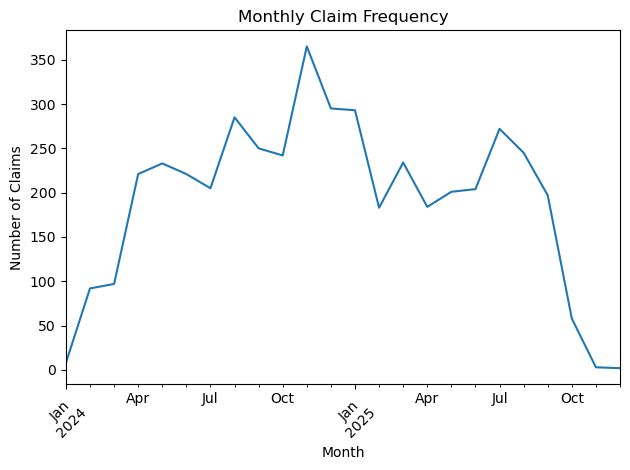

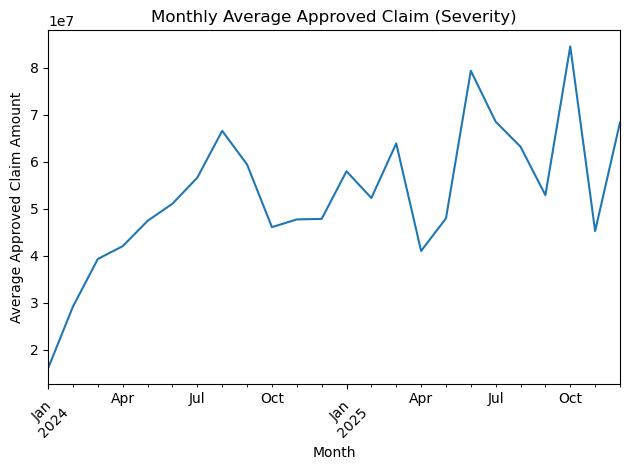

In [7]:
# 1. Convert date column to datetime
# ===============================
claim_data["Tanggal Pembayaran Klaim"] = pd.to_datetime(
    claim_data["Tanggal Pembayaran Klaim"],
    errors="coerce"
)

# Drop rows with missing payment dates
df_clean = claim_data.dropna(subset=["Tanggal Pembayaran Klaim"]).copy()

# ===============================
# 2. Create Year-Month column
# ===============================
df_clean["YearMonth"] = df_clean["Tanggal Pembayaran Klaim"].dt.to_period("M")

# ===============================
# 3. Monthly Claim Frequency
# ===============================
monthly_frequency = (
    df_clean
    .groupby("YearMonth")
    .size()
    .sort_index()
)

plt.figure()
monthly_frequency.plot()
plt.title("Monthly Claim Frequency")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===============================
# 4. Monthly Claim Severity
# ===============================
monthly_severity = (
    df_clean
    .groupby("YearMonth")["Nominal Klaim Yang Disetujui"]
    .mean()
    .sort_index()
)

plt.figure()
monthly_severity.plot()
plt.title("Monthly Average Approved Claim (Severity)")
plt.xlabel("Month")
plt.ylabel("Average Approved Claim Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()